<a href="https://colab.research.google.com/github/InesAnindiyta/inesanin/blob/master/big_data1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
pip install pyspark

In [19]:
pip install pandas

pengenalan dan praktik dasar pyspark dan pandas

In [22]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

data = [("Ali", "34", "web progammer", "hiking", "L"), ("Budi", "23", "desain gambar", "olahaga", "L"), ("Citra", "29", "desainer", "menyanyi", "P"), ("Dina", "45", "chef", "berkebun", "P")]
columns = ["Nama", "Usia", "pekerjaan", "hobi", "gender"]
df = spark.createDataFrame(data, columns)

df.show()

+-----+----+-------------+--------+------+
| Nama|Usia|    pekerjaan|    hobi|gender|
+-----+----+-------------+--------+------+
|  Ali|  34|web progammer|  hiking|     L|
| Budi|  23|desain gambar| olahaga|     L|
|Citra|  29|     desainer|menyanyi|     P|
| Dina|  45|         chef|berkebun|     P|
+-----+----+-------------+--------+------+



praktik pyspark lanjutan

In [26]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

data = [("Ali", "34", "web progammer", "hiking", "L"), ("Budi", "23", "desain gambar", "olahaga", "L"), ("Citra", "29", "desainer", "menyanyi", "P"), ("Dina", "45", "chef", "berkebun", "P")]
columns = ["Nama", "Usia", "pekerjaan", "hobi", "gender"]
df = spark.createDataFrame(data, columns)

df.show()

df_filtered = df.filter(df['Usia'] > 30)
df_filtered.show()

from pyspark.sql.functions import avg
df.groupBy().agg(avg("Usia")).show()

df_sorted = df.orderBy("Usia", ascending=False)
df_sorted.show()


+-----+----+-------------+--------+------+
| Nama|Usia|    pekerjaan|    hobi|gender|
+-----+----+-------------+--------+------+
|  Ali|  34|web progammer|  hiking|     L|
| Budi|  23|desain gambar| olahaga|     L|
|Citra|  29|     desainer|menyanyi|     P|
| Dina|  45|         chef|berkebun|     P|
+-----+----+-------------+--------+------+

+----+----+-------------+--------+------+
|Nama|Usia|    pekerjaan|    hobi|gender|
+----+----+-------------+--------+------+
| Ali|  34|web progammer|  hiking|     L|
|Dina|  45|         chef|berkebun|     P|
+----+----+-------------+--------+------+

+---------+
|avg(Usia)|
+---------+
|    32.75|
+---------+

+-----+----+-------------+--------+------+
| Nama|Usia|    pekerjaan|    hobi|gender|
+-----+----+-------------+--------+------+
| Dina|  45|         chef|berkebun|     P|
|  Ali|  34|web progammer|  hiking|     L|
|Citra|  29|     desainer|menyanyi|     P|
| Budi|  23|desain gambar| olahaga|     L|
+-----+----+-------------+--------+-----

praktik dengan pandas

In [27]:
import pandas as pd

data_pandas = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Usia": [34, 23, 29, 45]}
df_pandas = pd.DataFrame(data_pandas)

df_pandas

,Nama,Usia
0,Ali,34
1,Budi,23
2,Citra,29
3,Dina,45


praktik pandas lanjutan

    Nama  Usia      Pekerjaan
0    Ali    34  web progammer
1   Budi    23  desain gambar
2  Citra    29       desainer
3   Dina    45           chef
            Usia
count   4.000000
mean   32.750000
std     9.322911
min    23.000000
25%    27.500000
50%    31.500000
75%    36.750000
max    45.000000


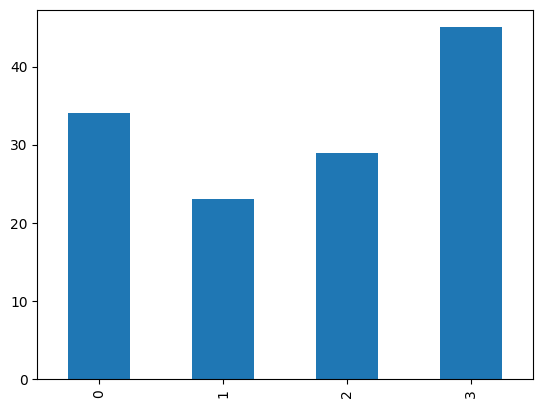

In [28]:
import pandas as pd

data_pandas = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Usia": [34, 23, 29, 45]}
df_pandas = pd.DataFrame(data_pandas)

data_pandas_2 = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Pekerjaan": ["web progammer", "desain gambar", "desainer", "chef"]}
df_pandas_2 = pd.DataFrame(data_pandas_2)

df_joined = pd.merge(df_pandas, df_pandas_2, on="Nama")
print(df_joined)

print(df_pandas.describe())

import matplotlib.pyplot as plt
df_pandas['Usia'].plot(kind='bar')
plt.show()


mengabungkan pyspark dan pandas

PySpark:
+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+

Konversi PySpark ke Pandas:
    Nama  Usia
0    Ali    34
1   Budi    23
2  Citra    29
3   Dina    45
Pandas:
    Nama      Pekerjaan      Hobi Gender
0    Ali  web progammer    hiking      L
1   Budi  desain gambar  olahraga      L
2  Citra       desainer   menyayi      P
3   Dina           chef  berkebun      P
Join:
    Nama  Usia      Pekerjaan      Hobi Gender
0    Ali    34  web progammer    hiking      L
1   Budi    23  desain gambar  olahraga      L
2  Citra    29       desainer   menyayi      P
3   Dina    45           chef  berkebun      P


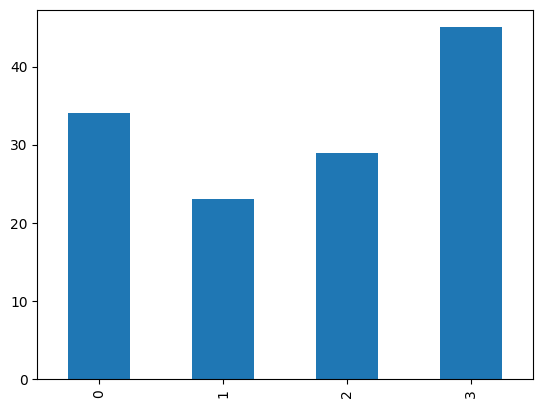

In [35]:
import pandas
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

pyspark_data = [
    ("Ali", 34),
    ("Budi", 23),
    ("Citra", 29),
    ("Dina", 45)]
pyspark_columns = ["Nama", "Usia"]
pyspark_df = spark.createDataFrame(pyspark_data, pyspark_columns)

print("PySpark:")
pyspark_df.show()

df_pandas_1 = pyspark_df.toPandas()

print("Konversi PySpark ke Pandas:")
print(df_pandas_1)

data_pandas_2 = {
    "Nama": ["Ali", "Budi", "Citra", "Dina"],
    "Pekerjaan": ["web progammer", "desain gambar", "desainer", "chef"],
    "Hobi": ["hiking", "olahraga", "menyayi", "berkebun"],
    "Gender": ["L", "L", "P", "P"]}
df_pandas_2 = pandas.DataFrame(data_pandas_2)

print("Pandas:")
print(df_pandas_2)

df_joined = pandas.merge(df_pandas_1, df_pandas_2, on="Nama")

print("Join:")
print(df_joined)

df_joined["Usia"].plot(kind="bar")
plt.show()

konversi data antara pyspark dan pandas

In [36]:
import pandas
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

pyspark_data = [
    ("Ali", 34),
    ("Budi", 23),
    ("Citra", 29),
    ("Dina", 45)]
pyspark_columns = ["Nama", "Usia"]
pyspark_df = spark.createDataFrame(pyspark_data, pyspark_columns)

print("PySpark:")
pyspark_df.show()

df_pandas_1 = pyspark_df.toPandas()

print("Konversi PySpark ke Pandas:")
print(df_pandas_1)

data_pandas_2 = {
    "Nama": ["Ali", "Budi", "Citra", "Dina"],
    "Pekerjaan": ["web progammer", "desain gambar", "desainer", "chef"],
    "Hobi": ["hiking", "olahraga", "menyayi", "berkebun"],
    "Gender": ["L", "L", "P", "P"]}
df_pandas_2 = pandas.DataFrame(data_pandas_2)

print("Pandas:")
print(df_pandas_2)

df_joined = pandas.merge(df_pandas_1, df_pandas_2, on="Nama")

print("Join:")
print(df_joined)

print("Beberapa operasi statistik dalam kolom \"Usia\"")
print(f"Tertinggi: {df_joined['Usia'].max()}")
print(f"Rata-rata: {df_joined['Usia'].mean()}")
print(f"Terendah: {df_joined['Usia'].min()}")
print(f"Median: {df_joined['Usia'].median()}")
print(f"Jumlah: {df_joined['Usia'].sum()}")


PySpark:
+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+

Konversi PySpark ke Pandas:
    Nama  Usia
0    Ali    34
1   Budi    23
2  Citra    29
3   Dina    45
Pandas:
    Nama      Pekerjaan      Hobi Gender
0    Ali  web progammer    hiking      L
1   Budi  desain gambar  olahraga      L
2  Citra       desainer   menyayi      P
3   Dina           chef  berkebun      P
Join:
    Nama  Usia      Pekerjaan      Hobi Gender
0    Ali    34  web progammer    hiking      L
1   Budi    23  desain gambar  olahraga      L
2  Citra    29       desainer   menyayi      P
3   Dina    45           chef  berkebun      P
Beberapa operasi statistik dalam kolom "Usia"
Tertinggi: 45
Rata-rata: 32.75
Terendah: 23
Median: 31.5
Jumlah: 131
